## Problem Statement
> Develop a binary classification model that predicts whether an observation belongs to the diabetic or non-diabetic class based on the available clinical features.

## Dataset
The dataset used is the Pima Indian Diabetes Database from Kaggle. The link is https://www.kaggle.com/datasets/mragpavank/diabetes

## Evaluation
> Primary model selection metric: Average Precision. The goal is to maximize how well the model ranks positive examples over negative ones while paying attention to the positive class.

> Primary decision metric: Recall. The goal is to minimize false negatives because failing to identify a patient who may have diabetes is considered more costly than generating a false positive. A target recall of 90% will be investigated, while also monitoring precision and other relevant metrics.

## Features
1. Pregnancies: Number of times pregnant.
2. Glucose: Plasma glucose concentration from a oral glucose tolerance test.
3. Blood Pressure: Diastolic blood pressure (mm Hg).
4. Skin Thickness: Triceps skin fold thickness (mm).
5. Insulin: 2-Hour serum insulin (μU/ml).
6. BMI: Body mass index (weight in kg/(height in m)²).
7. Diabetes Pedigree Function: Score providing information on diabetes history in relatives.
8. Age: Age in years.
9. Outcome (0 for non-diabetic, 1 for diabetic)

## Some Key EDA Findings

1. Class distribution: Outcome 0 accounts for approximately 65% of observations, while Outcome 1 accounts for approximately 35%.

2. Missing/invalid values: Several predictors contain zero values that may represent missing measurements, particularly Insulin (48.7%) and SkinThickness (29.6%).

3. Glucose: Outcome 1 observations generally have higher glucose values than Outcome 0 observations.

4. BMI: Outcome 1 observations tend to have higher BMI values, although substantial overlap exists.

5. Age: Age is positively skewed, with substantially more younger observations.

6. Insulin: Insulin has substantial dispersion and extreme values and will require further investigation during preprocessing.

7. Insulin: 51% of the Diabetic group (Outcome 1) has zero values while 47% of the Non-diabetic (Outcome 0) group has zero values

These findings will guide the data-cleaning and preprocessing decisions in the next stage.

### This is a remodel of the modelling notebook

## Models used for baseline
1. DummyClassifier: Serves as a sanity check for other models
2. LogisticRegression: Serves as a baseline to explore linear relationships
3. KNN: Useful for small datasets
4. SVC: To explore the non-linear boundaries
5. DecisionTreeClassifier: Tree-based Baseline for handling non-linear relationships
6. RandomForestClassifier: It is a more powerful tree-based model, less prone to overfitting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, classification_report, confusion_matrix, f1_score, precision_score, accuracy_score, RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
from joblib import load, dump

In [2]:
df = pd.read_csv('../data/diabetes.csv')

## Creating a Baseline Model

In [3]:
X = df.drop('Outcome', axis=1)
y = df.Outcome

In [4]:
# Stratification is used because the target variable is imbalanced
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [5]:
# Columns with encoded 0 missing values
zero_categories = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Remaining Columns
others_column = [col for col in X_train.columns if col not in zero_categories]

In [6]:
# Preprocessing steps
# Impute strategy - Median
# Scaler - StandardScaler

zero = Pipeline(steps=[
    ('impute', SimpleImputer(missing_values=0, strategy='median')),
    ('scaler', StandardScaler())
])
others = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessing = ColumnTransformer(transformers=[
    ('zero', zero, zero_categories),
    ('others', others, others_column)
], remainder='passthrough')

preprocessing_without_scale = ColumnTransformer(transformers=[
    ('impute', SimpleImputer(missing_values=0, strategy='median'), zero_categories)
], remainder='passthrough')

In [7]:
models = {
    'dummy classifier': DummyClassifier(strategy='stratified', random_state=42),
    'logistic regression': Pipeline(steps=[('preprocessing', preprocessing), ('model', LogisticRegression(random_state=42))]),
    'KNN': Pipeline(steps=[('preprocesing', preprocessing), ('model', KNeighborsClassifier(n_neighbors=5))]),
    'SVC': Pipeline(steps=[('preprocesing', preprocessing), ('model', SVC(probability=True, random_state=42))]),
    'Decision Tree': Pipeline(steps=[('preprocessing', preprocessing_without_scale), ('model', DecisionTreeClassifier(random_state=42))]),
    'Random Forest': Pipeline(steps=[('preprocessing', preprocessing_without_scale), ('model', RandomForestClassifier(random_state=42))])
}

In [8]:
# Scoring metrics
scoring = {
    'accuracy': 'accuracy',
     "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "average_precision": "average_precision"
}

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [10]:
results = {}

for model, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        verbose=2
    )

    results[model] = {
        "Accuracy Mean": scores["test_accuracy"].mean(),
        # "Accuracy Std": scores["test_accuracy"].std(),
        
        "Precision Mean": scores["test_precision"].mean(),
        # "Precision Std": scores["test_precision"].std(),
        
        "Recall Mean": scores["test_recall"].mean(),
        # "Recall Std": scores["test_recall"].std(),
        
        "F1 Mean": scores["test_f1"].mean(),
        # "F1 Std": scores["test_f1"].std(),
        
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        # "ROC-AUC Std": scores["test_roc_auc"].std(),
        
        "Balanced_Accuracy Mean": scores["test_balanced_accuracy"].mean(),
        # "Balanced_Accuracy Std": scores["test_balanced_accuracy"].std(),
        
        "Average_precision Mean": scores["test_average_precision"].mean(),
        # "Average_precision Std": scores["test_average_precision"].std()
    }

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.1s finished


[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.3s finished


[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.3s finished
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.1s


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.8s finished


[CV] END .................................................... total time=   0.1s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.3s finished


[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.5s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s
[CV] END .................................................... total time=   0.4s


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    2.6s finished


In [11]:
results_df = pd.DataFrame(results).T

In [12]:
results_df

,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,Balanced_Accuracy Mean,Average_precision Mean
dummy classifier,0.578155,0.390244,0.373754,0.381813,0.530627,0.530627,0.364968
logistic regression,0.788231,0.763808,0.574751,0.654545,0.843364,0.738625,0.747125
KNN,0.729588,0.636708,0.565449,0.593861,0.784332,0.691474,0.616013
SVC,0.780128,0.741534,0.584164,0.648462,0.833308,0.734582,0.726241
Decision Tree,0.679168,0.539606,0.546733,0.542422,0.648367,0.648367,0.453403
Random Forest,0.760589,0.693317,0.579734,0.627312,0.816324,0.718617,0.703715


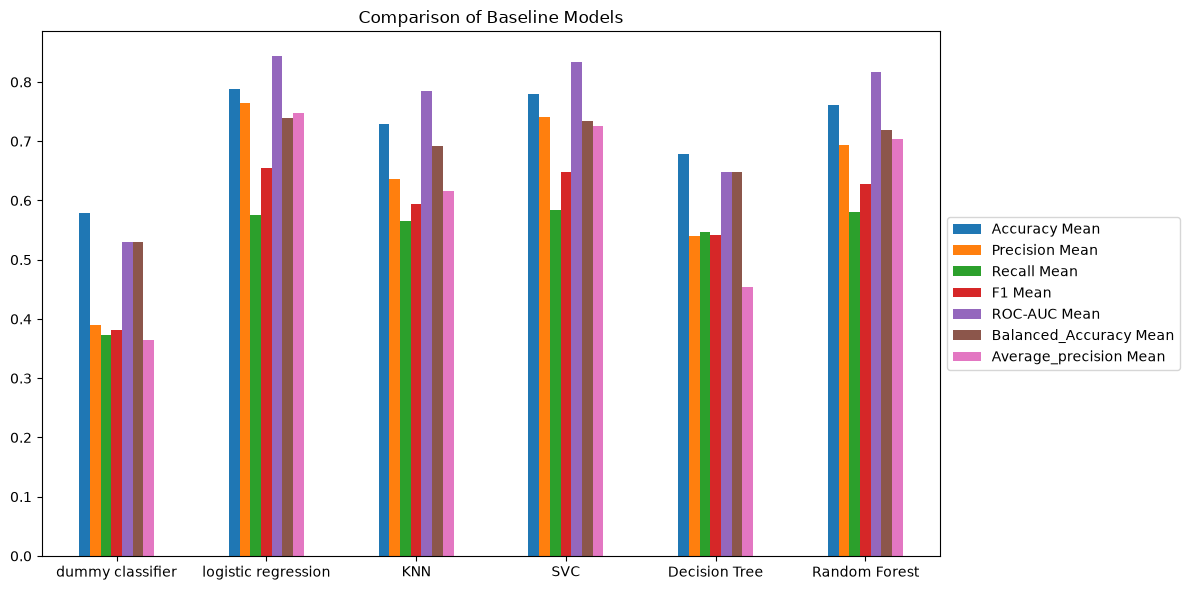

In [13]:
ax = results_df.plot.bar(
    title='Comparison of Baseline Models',
    figsize=(12, 6),
    rot=0
)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()

The baseline models that look promising are Logistic Regression, SVC and Random Forest. These models have the highest Average Precision Mean

## Hyperparameter Tuning

### Logistic Regression

In [14]:
lr_model = Pipeline(steps=[('preprocessing', preprocessing), ('model', LogisticRegression(random_state=42))])

In [15]:
grid = [
    {"model__C": [0.001, 0.01, 0.1, 1, 10, 100],
     "model__l1_ratio" : [0],
    "model__solver": ['lbfgs', 'liblinear'],
     "model__max_iter": range(10, 500, 100),
    "model__class_weight": [None, 'balanced']},

    {"model__C": [0.001, 0.01, 0.1, 1, 10, 100],
     "model__l1_ratio" : [1],
    "model__solver": ['saga', 'liblinear'],
     "model__max_iter": range(10, 500, 100),
    "model__class_weight": [None, 'balanced']}
]

In [16]:
def RandSearch(model, grid):
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=grid,
        n_iter=50,
        cv=cv,
        verbose=0,
        scoring='average_precision',
        random_state=42
    )
    
    search.fit(X_train, y_train)

    return search

def GridSearch(model, grid):
    search = GridSearchCV(
        estimator=model,
        param_grid=grid,
        cv=cv,
        verbose=0,
        scoring='average_precision'
    )
    
    search.fit(X_train, y_train)

    return search

In [17]:
lr_search = RandSearch(lr_model, grid)

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [18]:
lr_search.best_score_

np.float64(0.7516949416749877)

In [19]:
lr_search.best_params_

{'model__solver': 'liblinear',
 'model__max_iter': 210,
 'model__l1_ratio': 1,
 'model__class_weight': 'balanced',
 'model__C': 0.1}

In [20]:
grid_lr = [
    {"model__C": [0.01, 0.1, 1],
     "model__l1_ratio" : [1],
    "model__solver": ['liblinear'],
     "model__max_iter": [200, 350, 400],
    "model__class_weight": ['balanced']},
]

lr_grsearch = GridSearch(lr_model, grid_lr)

In [21]:
lr_grsearch.best_score_

np.float64(0.7516949416749877)

In [22]:
lr_grsearch.best_params_

{'model__C': 0.1,
 'model__class_weight': 'balanced',
 'model__l1_ratio': 1,
 'model__max_iter': 200,
 'model__solver': 'liblinear'}

In [23]:
def cv_evaluate(model):
    results = {}
    scores = cross_validate(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            verbose=0
        )
    
    results = {
            "Accuracy Mean": scores["test_accuracy"].mean(),        
            "Precision Mean": scores["test_precision"].mean(),
            "Recall Mean": scores["test_recall"].mean(),        
            "F1 Mean": scores["test_f1"].mean(),        
            "ROC-AUC Mean": scores["test_roc_auc"].mean(),        
            "Balanced_Accuracy Mean": scores["test_balanced_accuracy"].mean(),        
            "Average_precision Mean": scores["test_average_precision"].mean()
        }

    return results

In [24]:
lr_eval = cv_evaluate(lr_grsearch.best_estimator_)

In [25]:
comparison = pd.DataFrame([lr_eval], index=['LogisticRegression'])

### SVC 

In [26]:
svc_model = Pipeline(steps=[('preprocesing', preprocessing), ('model', SVC(probability=True, random_state=42))])

In [27]:
grid_dist = [
    {'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__kernel': ['linear'],
    'model__class_weight': [None, 'balanced']},

    {
     'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__kernel': ['rbf'],
        'model__class_weight': [None, 'balanced'],
        'model__gamma': [0.001, 0.01, 0.1, 1, 10, 100]
    }
]

In [28]:
svc_search = RandSearch(svc_model, grid_dist)

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The

In [29]:
svc_search.best_score_

np.float64(0.7536291662422087)

In [30]:
svc_search.best_params_

{'model__kernel': 'linear', 'model__class_weight': None, 'model__C': 10}

In [31]:
grid_param = {
    'model__kernel': ['linear'],
    'model__class_weight': ['balanced', None],
    'model__C': [0.01, 0.1, 1, 10, 100]
}

In [32]:
svc_grsearch = GridSearch(svc_model, grid_param)

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The

In [33]:
svc_grsearch.best_params_

{'model__C': 10, 'model__class_weight': None, 'model__kernel': 'linear'}

In [34]:
svc_eval = cv_evaluate(svc_grsearch.best_estimator_)

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The

In [35]:
comparison = pd.concat([comparison, pd.DataFrame([svc_eval], index=['SVC'])])

### RandomForestClassifier

In [36]:
rf_model = Pipeline(steps=[('preprocessing', preprocessing_without_scale), ('model', RandomForestClassifier(random_state=42))])

In [37]:
grid_dist = {
    'model__n_estimators': np.random.randint(10, 1000, size=5),
    'model__max_depth': [None, 5, 10, 20, 30, 50],
    'model__min_samples_split': [2, 5, 10, 20, 50],
    'model__min_samples_leaf': [1, 2, 4, 8, 10],
    'model__max_features': ['sqrt', 'log2', 0.2, 0.4, None],
    'model__class_weight': [None, 'balanced']
}


In [38]:
rf_search = RandSearch(rf_model, grid_dist)

In [39]:
rf_search.best_score_

np.float64(0.7436621193813503)

In [40]:
rf_search.best_params_

{'model__n_estimators': np.int32(642),
 'model__min_samples_split': 50,
 'model__min_samples_leaf': 2,
 'model__max_features': 'log2',
 'model__max_depth': 20,
 'model__class_weight': None}

In [41]:
grid = {'model__n_estimators': [600, 650],
 'model__min_samples_split': [50],
 'model__min_samples_leaf': [2],
 'model__max_features': ['log2'],
 'model__max_depth': [20],
 'model__class_weight': [None, 'balanced']}

In [42]:
rf_grsearch = GridSearch(rf_model, grid)

In [43]:
rf_grsearch.best_params_

{'model__class_weight': None,
 'model__max_depth': 20,
 'model__max_features': 'log2',
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 50,
 'model__n_estimators': 650}

In [44]:
rf_eval = cv_evaluate(rf_grsearch.best_estimator_)

In [45]:
comparison = pd.concat([comparison, pd.DataFrame([rf_eval], index=['RandomForestClassifier'])])

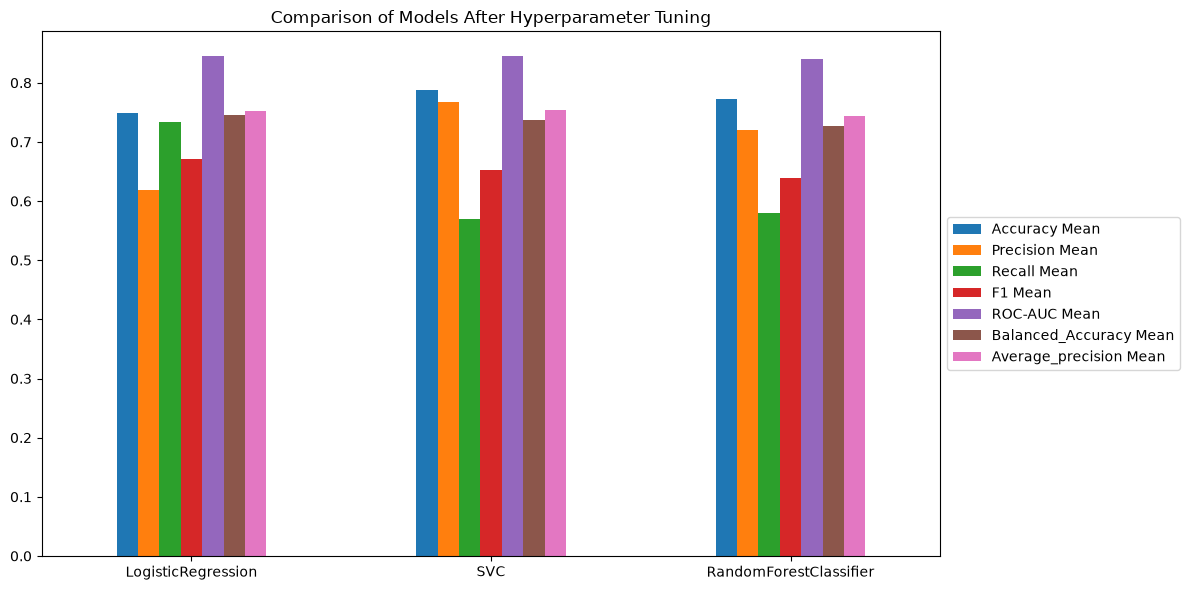

In [46]:
ax = comparison.plot.bar(
    title='Comparison of Models After Hyperparameter Tuning',
    figsize=(12, 6),
    rot=0
)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()

In [47]:
comparison

,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,Balanced_Accuracy Mean,Average_precision Mean
LogisticRegression,0.749180,0.618714,0.733666,0.670647,0.844600,0.745583,0.751695
SVC,0.788231,0.767192,0.570100,0.652373,0.844738,0.737550,0.753629
RandomForestClassifier,0.771958,0.720565,0.579513,0.639481,0.839759,0.727256,0.743894


Tuning improved the Average Precision of the models:
1. Logistic Regression - 0.74 -> 0.751
2. SVC - 0.72 -> 0.753
3. Random Forest - 0.70 -> 0.74

### Threshold Tuning

In [48]:
def threshold_tuning(model, X_train, y_train):
    oof_probs_positive = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:,1]
    thresholds = np.linspace(0.01, 0.99, 99)
    
    records = []
    
    for t in thresholds:
        preds = (oof_probs_positive >= t).astype(int)
    
        precision = precision_score(y_train, preds, zero_division=0)
        recall = recall_score(y_train, preds, zero_division=0)
        f1 = f1_score(y_train, preds, zero_division=0)
    
        records.append((t, precision, recall, f1))
    
    records = np.array(records)
    
    target_recall = 0.90
    
    candidates = records[records[:, 2] >= target_recall]
    
    if candidates.size == 0:
        print("No threshold reached the target recall.")
        print("Choosing threshold with maximum recall instead.")
    
        best = records[np.argmax(records[:, 2])]
    
    else:
        # Among thresholds with target recall, choose highest precision.
        # If precision is tied, choose higher recall.
        best = max(candidates, key=lambda x: (x[1], x[2], x[0]))
    
    best_threshold = best[0]
    best_precision = best[1]
    best_recall = best[2]
    best_f1 = best[3]
    
    print("Chosen threshold:", best_threshold)
    print("Precision:", best_precision)
    print("Recall:", best_recall)
    print("F1:", best_f1)

    return best

### Logistic Regression

In [49]:
tuned_lr = threshold_tuning(lr_grsearch.best_estimator_, X_train, y_train)

Chosen threshold: 0.36000000000000004
Precision: 0.5244565217391305
Recall: 0.9018691588785047
F1: 0.6632302405498282


### SVC

In [50]:
tuned_svc = threshold_tuning(svc_grsearch.best_estimator_, X_train, y_train)

C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The

Chosen threshold: 0.2
Precision: 0.5132978723404256
Recall: 0.9018691588785047
F1: 0.6542372881355932


### RandomForest

In [51]:
tuned_rf = threshold_tuning(rf_grsearch.best_estimator_, X_train, y_train)

Chosen threshold: 0.24000000000000002
Precision: 0.5244565217391305
Recall: 0.9018691588785047
F1: 0.6632302405498282


C:\Users\HP\Documents\diabetes_prediction\venv\Lib\site-packages\sklearn\utils\_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


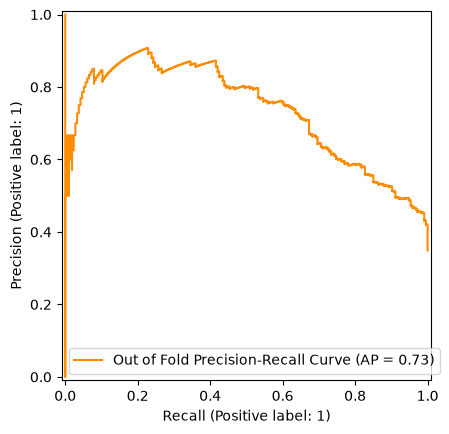

In [52]:
oof_probs_positive = cross_val_predict(lr_grsearch.best_estimator_, X_train, y_train, cv=cv, method='predict_proba')[:,1]
display = PrecisionRecallDisplay.from_predictions(y_train, oof_probs_positive, name='Out of Fold Precision-Recall Curve', color='darkorange')

Logistic Regression had the highest recall score with 0.90 with a precision of 0.52 at 0.36 threshold. This meets the goal to minimize false negatives because failing to identify a patient who may have diabetes is considered more costly than generating a false positive and to investigate a target recall of 90%.

# Final Evaluation

In [53]:
model = lr_grsearch.best_estimator_

In [54]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('zero', ...), ('others', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [55]:
y_test_proba = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.36000000000000004).astype(int)

In [56]:
def eval(y_test, y_test_pred):
    results = {}
    results['recall'] = recall_score(y_test, y_test_pred)
    results['precision'] = precision_score(y_test, y_test_pred)
    results['f1_score'] = f1_score(y_test, y_test_pred)
    results['accuracy'] = accuracy_score(y_test, y_test_pred)

    print(f'Accuracy Score: {results['accuracy']:.2f}')
    print(f'Precision Score: {results['precision']:.2f}')
    print(f'Recall Score: {results['recall']:.2f}')
    print(f'F1 Score: {results['f1_score']:.2f}')

In [57]:
eval(y_test, y_test_pred)

Accuracy Score: 0.71
Precision Score: 0.55
Recall Score: 0.89
F1 Score: 0.68


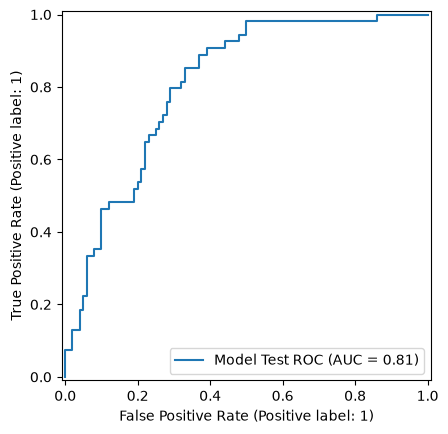

In [58]:
RocCurveDisplay.from_predictions(y_test, y_test_proba, name='Model Test ROC');

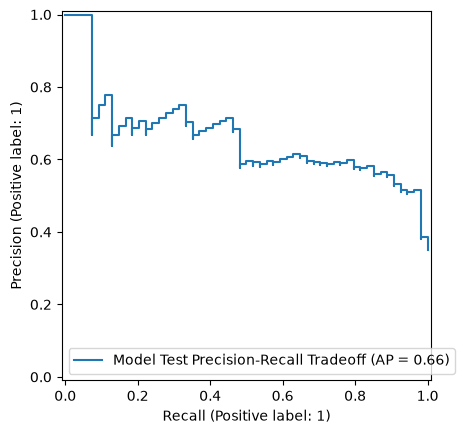

In [59]:
PrecisionRecallDisplay.from_predictions(y_test, y_test_proba, name='Model Test Precision-Recall Tradeoff');

In [60]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.91      0.61      0.73       100
           1       0.55      0.89      0.68        54

    accuracy                           0.71       154
   macro avg       0.73      0.75      0.71       154
weighted avg       0.78      0.71      0.71       154



In [61]:
confusion_matrix(y_test, y_test_pred)

array([[61, 39],
       [ 6, 48]])

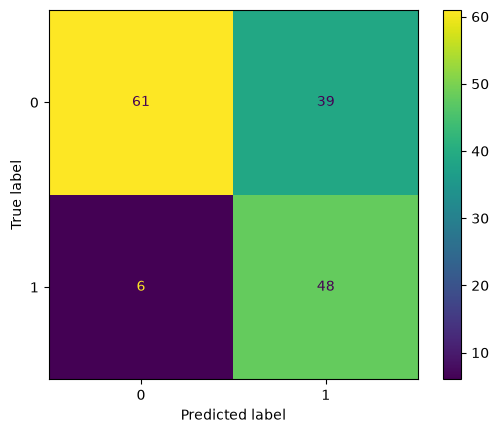

In [62]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred);

## Final model:
Logistic Regression

## Why:
- competitive recall
- better performance than baseline models

## Final preprocessing:
- median imputation
- StandardScaler


## Final hyperparameters:
- C: 0.1,
- class_weight: 'balanced'
- l1_ratio: 1
- max_iter: 200
- solver: 'liblinear'

## Final test performance:
- Accuracy Score: 0.71
- Precision Score: 0.55
- Recall Score: 0.89
- F1 Score: 0.68
- AUC: 0.81
- PR_AUC: 0.66

# Saving the model

In [63]:
model = lr_grsearch.best_estimator_

artifact = {
    'model': model,
    'threshold': 0.36,
    'best_params': lr_grsearch.best_params_
}

dump(artifact, '../models/best_model_and_threshold.joblib')

['../models/best_model_and_threshold.joblib']

## Error Analysis

In [64]:
## Create an error analysis table
df = pd.DataFrame(
    {
        'true': y_test,
        'prob_positive': y_test_proba,
        'pred': y_test_pred
    }
)

df['correct'] = df['true'] == df['pred']

conditions = [
    (df['true'] == 1) & (df['pred'] == 1),
    (df['true'] == 0) & (df['pred'] == 1),
    (df['true'] == 1) & (df['pred'] == 0),
    (df['true'] == 0) & (df['pred'] == 0)
]

choices = ['TP', 'FP', 'FN', 'TN']

df['outcome'] = np.select(conditions, choices, default='Unknown')

In [65]:
df

,true,prob_positive,pred,correct,outcome
44,0,0.727534,1,False,FP
672,0,0.234329,0,True,TN
700,0,0.486414,1,False,FP
630,1,0.398559,1,True,TP
81,0,0.094103,0,True,TN
...,...,...,...,...,...
32,0,0.095877,0,True,TN
637,0,0.208793,0,True,TN
593,0,0.193665,0,True,TN
425,1,0.908658,1,True,TP


In [66]:
errors = df[df["correct"] == False]

In [67]:
false_negativity = df[df['outcome']=='FN']
false_positive = df[df['outcome']=='FP']

In [68]:
false_positives_sorted = false_positive.sort_values(by='prob_positive', ascending=False)

In [69]:
X_test_with_info = X_test.copy()
X_test_with_info["true"] = y_test
X_test_with_info["prob_positive"] = y_test_proba
X_test_with_info["pred"] = y_test_pred
X_test_with_info["correct"] = y_test == y_test_pred
X_test_with_info["outcome"] = np.select(conditions, choices, default="Unknown")

In [70]:
X_test_with_info

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,true,prob_positive,pred,correct,outcome
44,7,159,64,0,0,27.4,0.294,40,0,0.727534,1,False,FP
672,10,68,106,23,49,35.5,0.285,47,0,0.234329,0,True,TN
700,2,122,76,27,200,35.9,0.483,26,0,0.486414,1,False,FP
630,7,114,64,0,0,27.4,0.732,34,1,0.398559,1,True,TP
81,2,74,0,0,0,0.0,0.102,22,0,0.094103,0,True,TN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32,3,88,58,11,54,24.8,0.267,22,0,0.095877,0,True,TN
637,2,94,76,18,66,31.6,0.649,23,0,0.208793,0,True,TN
593,2,82,52,22,115,28.5,1.699,25,0,0.193665,0,True,TN
425,4,184,78,39,277,37.0,0.264,31,1,0.908658,1,True,TP


In [71]:
fn_examples = X_test_with_info[
    X_test_with_info["outcome"] == "FN"
].sort_values("prob_positive", ascending=False)

fn_examples.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,true,prob_positive,pred,correct,outcome
419,3,129,64,29,115,26.4,0.219,28,1,0.343902,0,False,FN
17,7,107,74,0,0,29.6,0.254,31,1,0.319122,0,False,FN
124,0,113,76,0,0,33.3,0.278,23,1,0.290183,0,False,FN
38,2,90,68,42,0,38.2,0.503,27,1,0.278228,0,False,FN
276,7,106,60,24,0,26.5,0.296,29,1,0.258943,0,False,FN
6,3,78,50,32,88,31.0,0.248,26,1,0.115145,0,False,FN


In [72]:
fp_examples = X_test_with_info[
    X_test_with_info["outcome"] == "FP"
].sort_values("prob_positive", ascending=False)

fp_examples.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,true,prob_positive,pred,correct,outcome
489,8,194,80,0,0,26.1,0.551,67,0,0.930512,1,False,FP
247,0,165,90,33,680,52.3,0.427,23,0,0.930275,1,False,FP
212,7,179,95,31,0,34.2,0.164,60,0,0.915977,1,False,FP
469,6,154,78,41,140,46.1,0.571,27,0,0.909551,1,False,FP
335,0,165,76,43,255,47.9,0.259,26,0,0.896837,1,False,FP
260,3,191,68,15,130,30.9,0.299,34,0,0.880261,1,False,FP
258,1,193,50,16,375,25.9,0.655,24,0,0.826829,1,False,FP
436,12,140,85,33,0,37.4,0.244,41,0,0.826803,1,False,FP
660,10,162,84,0,0,27.7,0.182,54,0,0.809859,1,False,FP
153,1,153,82,42,485,40.6,0.687,23,0,0.804303,1,False,FP


In [73]:
df['Insulin'] = X_test['Insulin'].values
slice_report = df.groupby('Insulin').agg(
    count=('correct', 'size'),
    errors=("correct", lambda x: (~x).sum()),
    error_rate=("correct", lambda x: 1 - x.mean())
)

slice_report

,count,errors,error_rate
Insulin,,,
0,84,23,0.27381
14,1,0,0.00000
37,1,0,0.00000
45,1,0,0.00000
49,1,0,0.00000
...,...,...,...
480,1,1,1.00000
485,1,1,1.00000
600,1,0,0.00000


The model has difficulty with predicting samples with Insulin with 0 value. It has been addressed in the EDA as potential missing values.

In [74]:
slice_report = X_test_with_info.groupby('Insulin').agg(
    total_samples = ('correct', 'size'),
    false_positives = ('outcome', lambda x: (x == 'FP').sum())
)

slice_report

,total_samples,false_positives
Insulin,,
0,84,19
14,1,0
37,1,0
45,1,0
49,1,0
...,...,...
480,1,1
485,1,1
600,1,0


In [75]:
fpr = 19 / 84
fpr

0.2261904761904762

In [76]:
slice_report = X_test_with_info.groupby('Pregnancies').agg(
    total_samples = ('correct', 'size'),
    false_positives = ('outcome', lambda x: (x == 'FP').sum())
)

slice_report

,total_samples,false_positives
Pregnancies,,
0,26,8
1,23,3
2,19,4
3,18,2
4,15,4
5,7,2
6,8,2
7,11,4
8,8,4


In [77]:
slice_report = X_test_with_info.groupby('Glucose').agg(
    total_samples = ('correct', 'size'),
    false_positives = ('outcome', lambda x: (x == 'FP').sum())
)

slice_report

,total_samples,false_positives
Glucose,,
0,1,0
44,1,0
57,1,0
67,1,0
68,1,0
...,...,...
189,2,0
191,1,1
193,2,1


In [78]:
df['Pregnancies'] = X_test['Pregnancies'].values
df['Pregnancies_bin'] = pd.cut(df['Pregnancies'], bins=5)

In [79]:
slice_report = df.groupby('Pregnancies_bin', observed=False).agg(
    count=('correct', 'size'),
    errors=("correct", lambda x: (~x).sum()),
    error_rate=("correct", lambda x: 1 - x.mean())
)

slice_report

,count,errors,error_rate
Pregnancies_bin,,,
"(-0.015, 3.0]",86,21,0.244186
"(3.0, 6.0]",30,8,0.266667
"(6.0, 9.0]",24,10,0.416667
"(9.0, 12.0]",10,5,0.500000
"(12.0, 15.0]",4,1,0.250000
